In [1]:
# %% [1] LIBRERÍAS -----------------------------------------------------------
!pip install semopy --quiet

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import semopy
from semopy import Model, calc_stats

warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.3 MB/s eta 0:00:00


In [2]:
# %% [2] CARGA DE DATOS -------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

RUTA = "/content/drive/MyDrive/Analisis fianal_vr.xlsx"
HOJA = "Datos sin procesar (2)"

df = pd.read_excel(RUTA, sheet_name=HOJA)
df.columns = df.columns.str.strip()
print("Dimensiones:", df.shape)

Mounted at /content/drive
Dimensiones: (505, 40)


In [3]:
# %% [3] DETECCIÓN Y LIMPIEZA DE LOS ÍTEMS -----------------------------------
# Detecta automáticamente todas las columnas de ítems: "Área 1 - ...", "Área 2 - ...", etc.
item_cols = [c for c in df.columns if re.match(r'^Área\s*\d+\s*-', c.strip())]
print(f"Ítems detectados: {len(item_cols)}")

# Forzar a numérico
df[item_cols] = df[item_cols].apply(pd.to_numeric, errors='coerce')

# Imputar perdidos con la mediana (igual que en tu notebook original)
for col in item_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Tratamiento de atípicos por winsorización suave (1%-99%) para no perder filas
for col in item_cols:
    p01, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=p01, upper=p99)

Ítems detectados: 22


In [4]:
# %% [4] RENOMBRAR ÍTEMS A CÓDIGOS CORTOS (necesario para la sintaxis SEM) ---
area_pattern = re.compile(r'Área\s*(\d+)')
area_groups = {}
for col in item_cols:
    area_num = int(area_pattern.search(col).group(1))
    area_groups.setdefault(area_num, []).append(col)

rename_map = {}
for area_num, cols in sorted(area_groups.items()):
    for i, col in enumerate(cols, start=1):
        rename_map[col] = f"A{area_num}_{i}"

df = df.rename(columns=rename_map)

print("\nMapeo de ítems por área:")
for area_num, cols in sorted(area_groups.items()):
    print(f" Área {area_num}: {[rename_map[c] for c in cols]}")


Mapeo de ítems por área:
 Área 1: ['A1_1', 'A1_2', 'A1_3', 'A1_4']
 Área 2: ['A2_1', 'A2_2', 'A2_3']
 Área 3: ['A3_1', 'A3_2', 'A3_3', 'A3_4']
 Área 4: ['A4_1', 'A4_2', 'A4_3']
 Área 5: ['A5_1', 'A5_2', 'A5_3']
 Área 6: ['A6_1', 'A6_2', 'A6_3', 'A6_4', 'A6_5']


In [5]:
# %% [5] MODELO SEM -----------------------------------------------------------
# Modelo de medida de 2do orden:
#   - Cada Área (Area1..Area6) es un factor latente medido por sus ítems observados.
#   - CDD (Competencia Digital Docente) es un factor de 2do orden explicado por las 6 áreas.

lines = []
for area_num, cols in sorted(area_groups.items()):
    inds = " + ".join([rename_map[c] for c in cols])
    lines.append(f"Area{area_num} =~ {inds}")

lines.append("CDD =~ " + " + ".join([f"Area{n}" for n in sorted(area_groups.keys())]))

model_desc = "\n".join(lines)
print("Sintaxis del modelo SEM:\n")
print(model_desc)

modelo_sem = Model(model_desc)
res = modelo_sem.fit(df)

print("\n===== ESTIMACIONES DEL MODELO SEM (cargas, varianzas, etc.) =====")
print(modelo_sem.inspect())

Sintaxis del modelo SEM:

Area1 =~ A1_1 + A1_2 + A1_3 + A1_4
Area2 =~ A2_1 + A2_2 + A2_3
Area3 =~ A3_1 + A3_2 + A3_3 + A3_4
Area4 =~ A4_1 + A4_2 + A4_3
Area5 =~ A5_1 + A5_2 + A5_3
Area6 =~ A6_1 + A6_2 + A6_3 + A6_4 + A6_5
CDD =~ Area1 + Area2 + Area3 + Area4 + Area5 + Area6

===== ESTIMACIONES DEL MODELO SEM (cargas, varianzas, etc.) =====
     lval  op   rval  Estimate  Std. Err    z-value   p-value
0   Area1   ~    CDD  1.000000         -          -         -
1   Area2   ~    CDD  1.508012  0.186935   8.067046       0.0
2   Area3   ~    CDD  2.444307  0.270344    9.04146       0.0
3   Area4   ~    CDD  1.863416  0.213475    8.72896       0.0
4   Area5   ~    CDD  2.220825  0.267967   8.287674       0.0
5   Area6   ~    CDD  2.107092  0.244588   8.614855       0.0
6    A1_1   ~  Area1  1.000000         -          -         -
7    A1_2   ~  Area1  1.582182  0.197848   7.996944       0.0
8    A1_3   ~  Area1  1.662738  0.196704   8.453003       0.0
9    A1_4   ~  Area1  1.427884  0.1823

In [6]:
# %% [6] ÍNDICES DE AJUSTE DEL MODELO SEM ------------------------------------
stats = calc_stats(modelo_sem)
print("\n===== ÍNDICES DE AJUSTE (chi2, CFI, TLI, RMSEA, GFI, AIC, BIC) =====")
print(stats.T)
# Referencia de interpretación:
#   CFI / TLI >= 0.90 (idealmente >= 0.95)  -> buen ajuste
#   RMSEA <= 0.08 (idealmente <= 0.05)      -> buen ajuste
#   chi2/df < 3                              -> buen ajuste


===== ÍNDICES DE AJUSTE (chi2, CFI, TLI, RMSEA, GFI, AIC, BIC) =====
                     Value
DoF             203.000000
DoF Baseline    231.000000
chi2            457.712870
chi2 p-value      0.000000
chi2 Baseline  4051.857167
CFI               0.933336
GFI               0.887036
AGFI              0.871455
NFI               0.887036
TLI               0.924141
RMSEA             0.049896
AIC              98.187276
BIC             309.415197
LogLik            0.906362


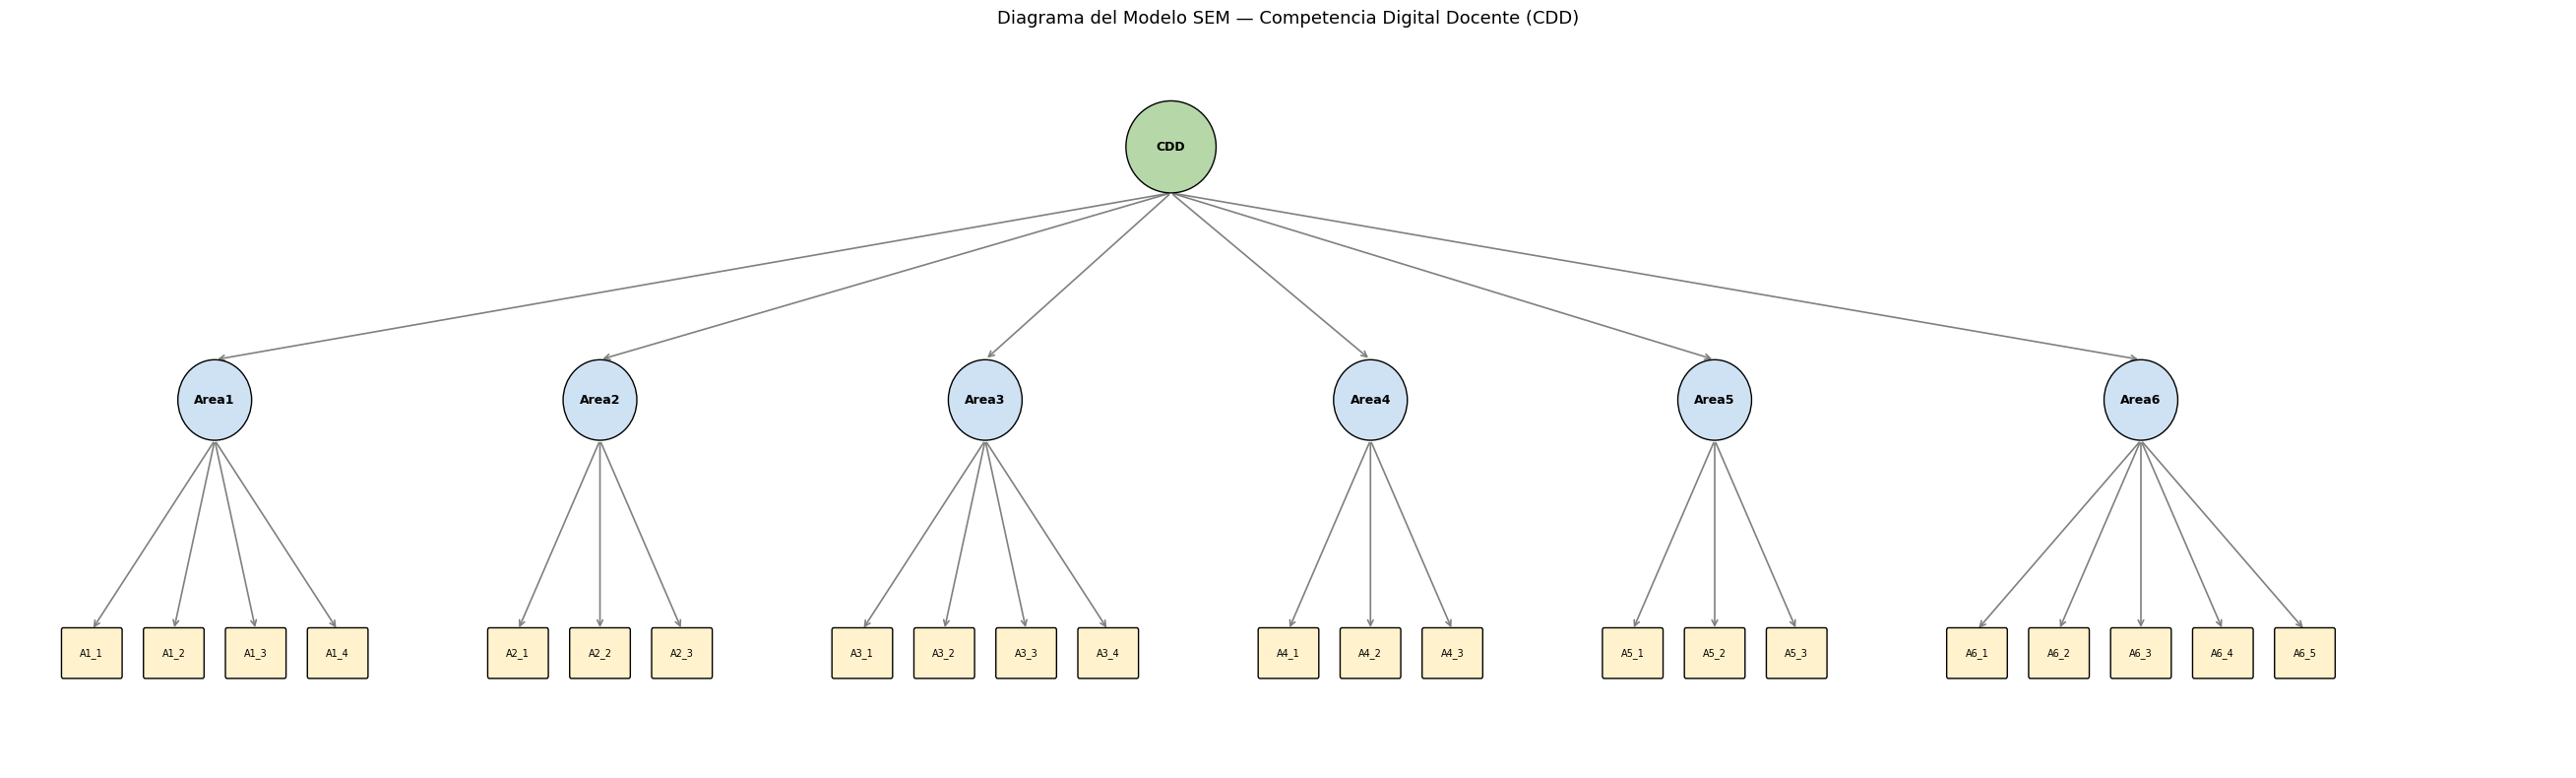

In [7]:

# %% [7] DIAGRAMA DEL MODELO SEM (con matplotlib, sin instalar nada) --------
import matplotlib.patches as mpatches

# --- 1) Extraer las cargas (loadings) estimadas del modelo ajustado ---------
res_tab = modelo_sem.inspect()
res_tab.columns = [c.strip() for c in res_tab.columns]
# Columnas típicas de semopy: lval, op, rval, Estimate, Std. Err, z-value, p-value
loadings = res_tab[res_tab["op"] == "=~"].copy()
loadings["Estimate"] = pd.to_numeric(loadings["Estimate"], errors="coerce").round(2)

def get_loading(padre, hijo):
    fila = loadings[(loadings["lval"] == padre) & (loadings["rval"] == hijo)]
    if len(fila):
        return fila["Estimate"].values[0]
    return None

# --- 2) Definir posiciones de cada nodo -------------------------------------
areas_ordenadas = sorted(area_groups.keys())
items_por_area = {f"Area{n}": [rename_map[c] for c in area_groups[n]] for n in areas_ordenadas}

# posiciones x de los ítems (fila inferior), en orden por área
x_items = {}
x_cursor = 0
espacio_item = 1.0
espacio_entre_areas = 1.2
for n in areas_ordenadas:
    for it in items_por_area[f"Area{n}"]:
        x_items[it] = x_cursor
        x_cursor += espacio_item
    x_cursor += espacio_entre_areas

# posición x de cada Área = centro de sus ítems
x_areas = {}
for n in areas_ordenadas:
    xs = [x_items[it] for it in items_por_area[f"Area{n}"]]
    x_areas[f"Area{n}"] = np.mean(xs)

# posición x de CDD = centro de todas las áreas
x_cdd = np.mean(list(x_areas.values()))

y_items, y_areas, y_cdd = 0, 2.2, 4.4  # alturas de cada nivel

# --- 3) Dibujar --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(max(14, x_cursor * 0.9), 8))

def draw_ellipse(x, y, texto, w=0.9, h=0.7, color="#cfe2f3"):
    e = mpatches.Ellipse((x, y), w, h, facecolor=color, edgecolor="black", zorder=3)
    ax.add_patch(e)
    ax.text(x, y, texto, ha="center", va="center", fontsize=9, fontweight="bold", zorder=4)

def draw_rect(x, y, texto, w=0.7, h=0.4, color="#fff2cc"):
    r = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                 boxstyle="round,pad=0.02",
                                 facecolor=color, edgecolor="black", zorder=3)
    ax.add_patch(r)
    ax.text(x, y, texto, ha="center", va="center", fontsize=7, zorder=4)

def draw_arrow(x1, y1, x2, y2, etiqueta=None):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="gray"), zorder=2)
    if etiqueta is not None:
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(xm, ym, f"{etiqueta}", fontsize=7, color="darkred",
                 ha="center", va="center", backgroundcolor="white", zorder=5)

# Nodo CDD
draw_ellipse(x_cdd, y_cdd, "CDD", w=1.1, h=0.8, color="#b6d7a8")

# Áreas y flechas CDD -> Área
for n in areas_ordenadas:
    nombre_area = f"Area{n}"
    draw_ellipse(x_areas[nombre_area], y_areas, nombre_area)
    carga = get_loading("CDD", nombre_area)
    draw_arrow(x_cdd, y_cdd - 0.4, x_areas[nombre_area], y_areas + 0.35, carga)

    # Ítems y flechas Área -> ítem
    for it in items_por_area[nombre_area]:
        draw_rect(x_items[it], y_items, it)
        carga_item = get_loading(nombre_area, it)
        draw_arrow(x_areas[nombre_area], y_areas - 0.35, x_items[it], y_items + 0.2, carga_item)

ax.set_xlim(-1, x_cursor + 1)
ax.set_ylim(-1, y_cdd + 1)
ax.axis("off")
ax.set_title("Diagrama del Modelo SEM — Competencia Digital Docente (CDD)", fontsize=13)
plt.tight_layout()
plt.savefig("sem_model.png", dpi=150)
plt.show()


In [8]:
# %% [8] MODELO 2: CLUSTERING (K-MEANS) --------------------------------------
# =============================================================================
# Se usan los puntajes ya agregados por área (columnas ÁREA 1 ... ÁREA 6)

area_score_cols = [c for c in ['ÁREA 1', 'ÁREA 2', 'ÁREA 3', 'ÁREA 4', 'ÁREA 5', 'ÁREA 6']
                    if c in df.columns]
print("Columnas usadas para el clustering:", area_score_cols)

df[area_score_cols] = df[area_score_cols].apply(pd.to_numeric, errors='coerce')
df_cluster = df.dropna(subset=area_score_cols).copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cluster[area_score_cols])

Columnas usadas para el clustering: ['ÁREA 1', 'ÁREA 2', 'ÁREA 3', 'ÁREA 4', 'ÁREA 5', 'ÁREA 6']


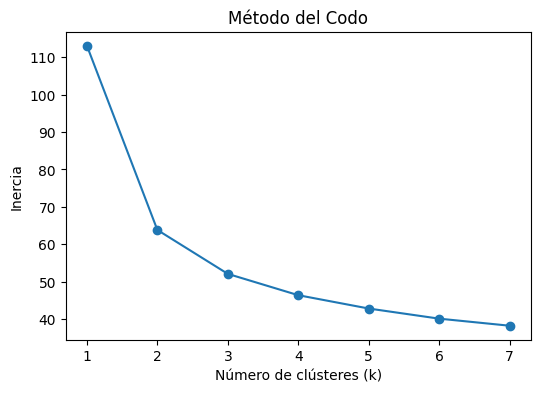

In [9]:
# %% [9] MÉTODO DEL CODO PARA ELEGIR EL NÚMERO DE CLÚSTERES ------------------
inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [10]:
# %% [10] AJUSTE FINAL DE K-MEANS ---------------------------------------------
N_CLUSTERS = 3  # ajusta este valor según el codo del gráfico anterior

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nDocentes por clúster:")
print(df_cluster["Cluster"].value_counts().sort_index())

print("\nPerfil promedio (puntaje real) por clúster:")
print(df_cluster.groupby("Cluster")[area_score_cols].mean().round(2))


Docentes por clúster:
Cluster
0    202
1    146
2    155
Name: count, dtype: int64

Perfil promedio (puntaje real) por clúster:
         ÁREA 1  ÁREA 2  ÁREA 3  ÁREA 4  ÁREA 5  ÁREA 6
Cluster                                                
0         10.34    8.31   11.73    7.78    8.13   12.59
1         12.07    9.64   14.15   10.38   10.40   16.64
2          8.02    6.47    8.19    5.90    5.14    9.39


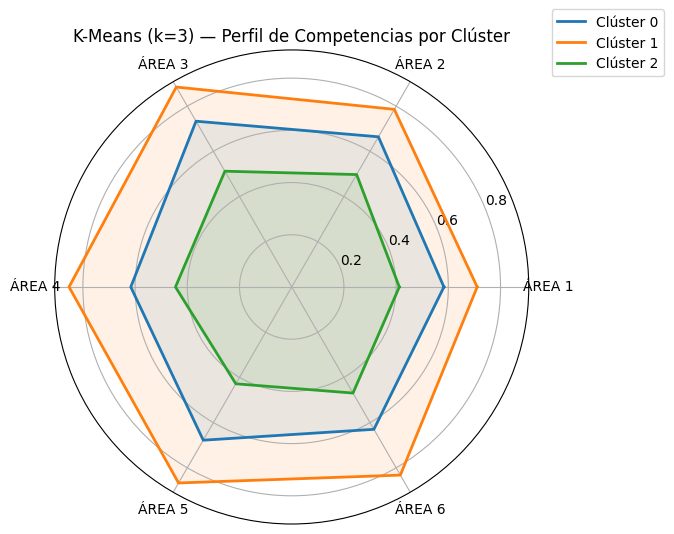

In [11]:
# %% [11] GRÁFICO RADAR POR CLÚSTER ------------------------------------------
areas_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(df_cluster[area_score_cols]),
    columns=area_score_cols, index=df_cluster.index
)
areas_norm["Cluster"] = df_cluster["Cluster"]
radar = areas_norm.groupby("Cluster")[area_score_cols].mean().reset_index()

labels_radar = area_score_cols
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
for _, row in radar.iterrows():
    vals = row[area_score_cols].values
    vals = np.concatenate((vals, [vals[0]]))
    ax.plot(angles, vals, linewidth=2, label=f"Clúster {int(row['Cluster'])}")
    ax.fill(angles, vals, alpha=0.10)

ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels_radar)
ax.set_title(f"K-Means (k={N_CLUSTERS}) — Perfil de Competencias por Clúster")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()